<a href="https://colab.research.google.com/github/duncanian303-cloud/Tsunami-earthquakes-detection/blob/main/Tsunamidetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd

df = pd.read_csv('/content/earthquake_data_tsunami.csv')
display(df.head())

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [87]:
import pandas as pd
import numpy as np

# Earth's radius, as established in the kernel state
R = 6371

# Reload the original DataFrame from the CSV
df = pd.read_csv('/content/earthquake_data_tsunami.csv')

print("DataFrame reloaded from CSV.")

DataFrame reloaded from CSV.


In [88]:
# Drop the 'Date_year', 'Year_of_Event', 'Year', and 'Month' columns
df = df.drop(columns=['Date_year', 'Year_of_Event', 'Year', 'Month'], errors='ignore')

print("Date and year-related columns dropped.")

Date and year-related columns dropped.


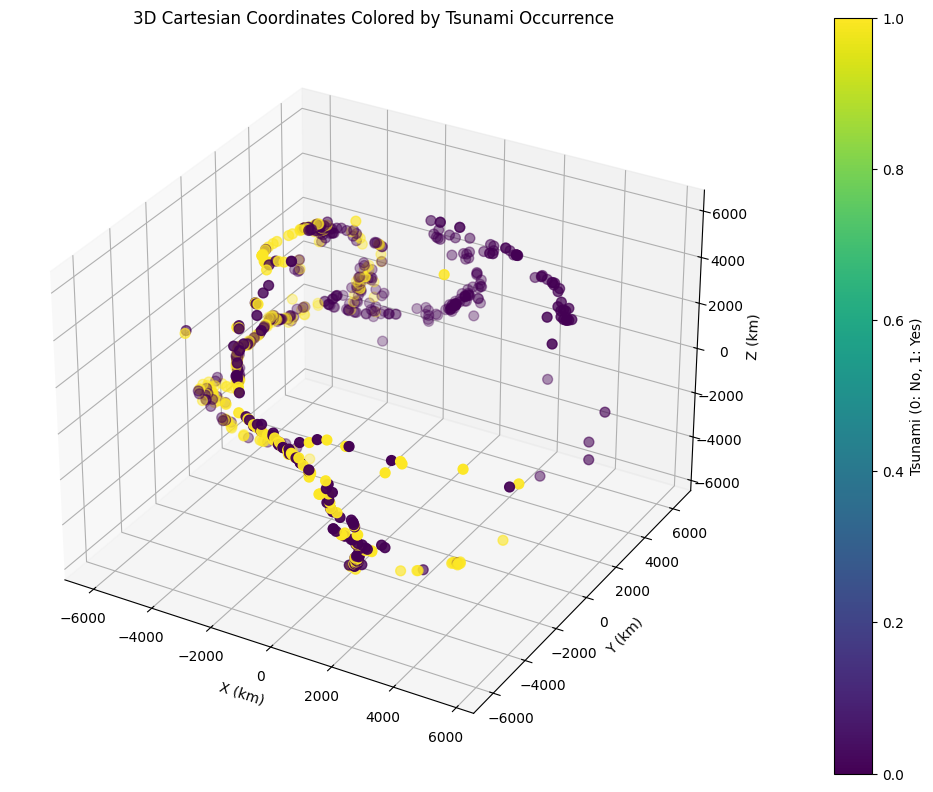

In [96]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot, colored by the 'tsunami' column
scatter = ax.scatter(df['X'], df['Y'], df['Z'], c=df['tsunami'], cmap='viridis', s=50)

# Add labels and title
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('3D Cartesian Coordinates Colored by Tsunami Occurrence')

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Tsunami (0: No, 1: Yes)')

plt.tight_layout()
plt.show()

In [90]:
# Drop 'cdi', 'mmi', and 'sig' columns as per the user's decision, ensuring 'magnitude' is NOT dropped
df = df.drop(columns=['cdi', 'mmi', 'sig'], errors='ignore')

print("Columns 'cdi', 'mmi', and 'sig' dropped from the DataFrame. Confirming 'magnitude' is still present.")

# Display the DataFrame head and info to confirm the columns
display(df.head())
display(df.info())

Columns 'cdi', 'mmi', and 'sig' dropped from the DataFrame. Confirming 'magnitude' is still present.


,magnitude,nst,dmin,gap,depth,tsunami,X,Y,Z
0,7.0,117,0.509,17.0,14.000,1,-5884.200768,2188.782273,-1083.999299
1,6.9,99,2.229,34.0,25.000,0,-1182.595943,6236.039228,-550.384037
2,7.0,147,3.125,18.0,579.000,1,-5982.353811,-172.745057,-2184.317520
3,7.3,149,1.865,21.0,37.000,1,-5956.605686,-823.474598,-2104.846618
4,6.6,131,4.998,27.0,624.464,1,-5743.229999,172.662297,-2752.296842


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   nst        782 non-null    int64  
 2   dmin       782 non-null    float64
 3   gap        782 non-null    float64
 4   depth      782 non-null    float64
 5   tsunami    782 non-null    int64  
 6   X          782 non-null    float64
 7   Y          782 non-null    float64
 8   Z          782 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 55.1 KB


None

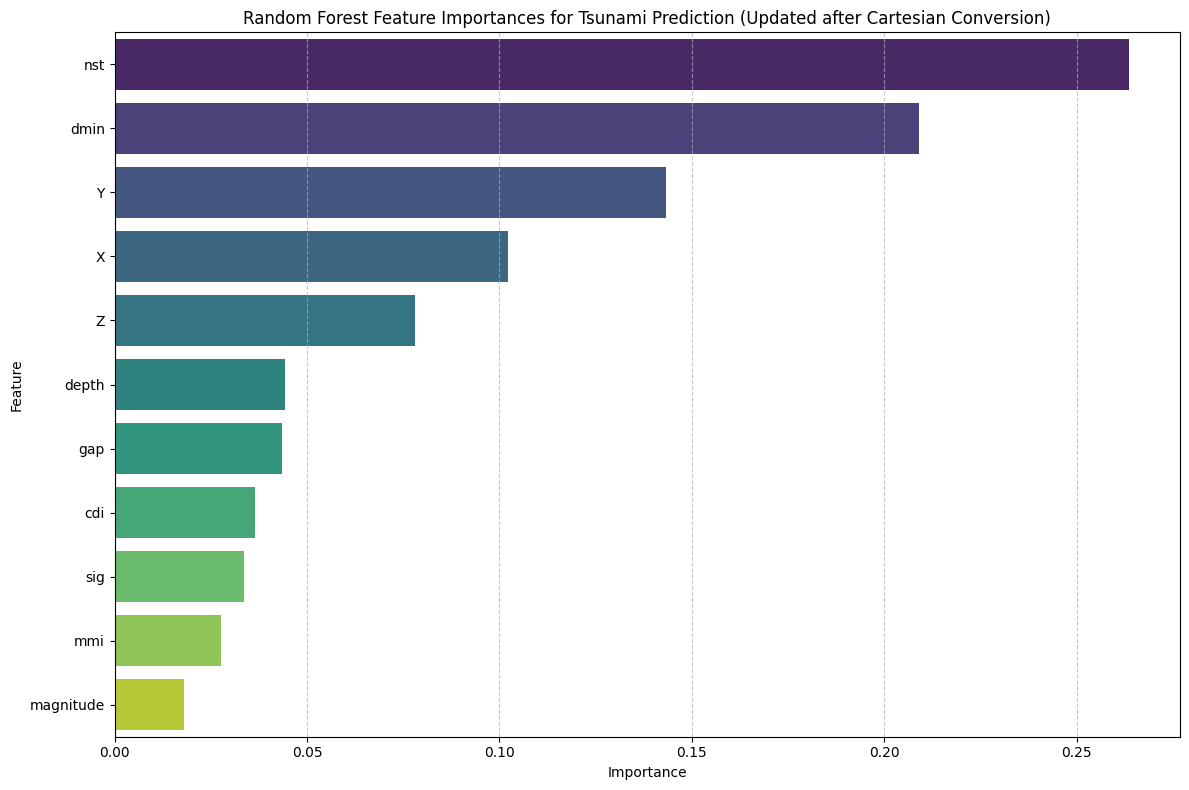

In [91]:
# Plot feature importances for better visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis', hue=feature_importances.index, legend=False)
plt.title('Random Forest Feature Importances for Tsunami Prediction (Updated after Cartesian Conversion)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [92]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('tsunami', axis=1)
y = df['tsunami']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (625, 8)
X_test shape: (157, 8)
y_train shape: (625,)
y_test shape: (157,)


In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize the Random Forest Classifier with class_weight for imbalanced data
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model
model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


In [94]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9108
Precision: 0.8730
Recall: 0.9016
F1-Score: 0.8871

Confusion Matrix:
[[88  8]
 [ 6 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        96
           1       0.87      0.90      0.89        61

    accuracy                           0.91       157
   macro avg       0.90      0.91      0.91       157
weighted avg       0.91      0.91      0.91       157

